# 1. EJEMPLO COMPARATIVO -> IRIS
El dataset Iris es un conjunto de datos que contiene información sobre flores del género Iris, concretamente de 3 especies:

- setosa
- versicolor
- virginica

Cada flor está descrita mediante 4 variables numéricas:

- Longitud del sépalo
- Anchura del sépalo
- Longitud del pétalo
- Anchura del pétalo

Y además tiene una etiqueta (la especie).
Puedes consultar más sobre este dataset en https://archive.ics.uci.edu/dataset/53/iris

En este notebook vamos a comparar dos enfoques distintos:

- un modelo de aprendizaje supervisado, que aprende usando etiquetas reales;
- un modelo K-Means, que agrupa observaciones sin conocer la especie.

La idea es comprobar que ambos pueden generar agrupaciones parecidas, pero no resuelven el mismo problema.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Cargar Iris

In [9]:
# Mantén este código. En él se carga el Dataset como un Objeto
iris = load_iris()

X = iris.data
y = iris.target

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Nombres de las clases:", iris.target_names)

df = pd.DataFrame(X, columns=iris.feature_names)
df["clase"] = y
df["nombre_clase"] = df["clase"].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

df.head()

Forma de X: (150, 4)
Forma de y: (150,)
Nombres de las clases: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),clase,nombre_clase
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2.1 NOrmalización

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos normalizados (primeras filas):")
print(X_scaled[:5])

Datos normalizados (primeras filas):
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


## 2.2 Método del Codo

<Figure size 700x500 with 0 Axes>

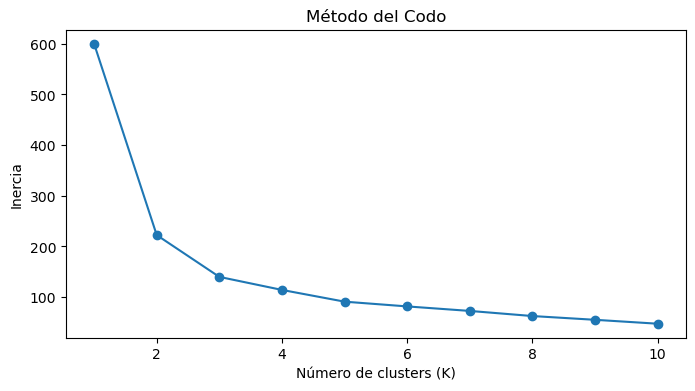

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled) # X_scaled es el dataset normalizado
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1, 11), inercia, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.show()

# 3. Visualización sencilla de dos variables

Para representar el dataset de forma clara, vamos a usar dos variables:

- longitud del pétalo
- anchura del pétalo

Estas variables suelen separar mejor las especies que las medidas del sépalo.

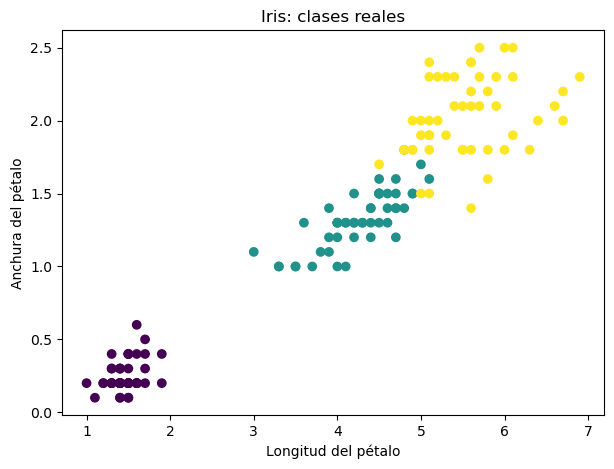

In [23]:
plt.figure(figsize=(7,5))
plt.scatter(X[:, 2], X[:, 3], c=y)
plt.xlabel("Longitud del pétalo")
plt.ylabel("Anchura del pétalo")
plt.title("Iris: clases reales")
plt.show()

# 4. Modelo Supervisado

## 4.1 Interpretación del modelo supervisado

En este caso, el modelo sí conoce las etiquetas reales durante el entrenamiento.

Por eso puede:

- aprender a distinguir especies;
- predecir la clase de nuevas flores;
- comparar sus predicciones con la realidad mediante métricas como la `accuracy` o la matriz de confusión.

In [ ]:
# 1. Crear el modelo de Regresión Logística
# Nota: Usamos max_iter=200 para asegurar que el modelo converja
modelo_sup = LogisticRegression(max_iter=200)

# 2. Entrenar el modelo (aquí es donde el modelo "conoce" las etiquetas reales y)
modelo_sup.fit(X, y)

# 3. Realizar predicciones
y_pred_sup = modelo_sup.predict(X)


## 4.2 Visualización prediciones supervisadas

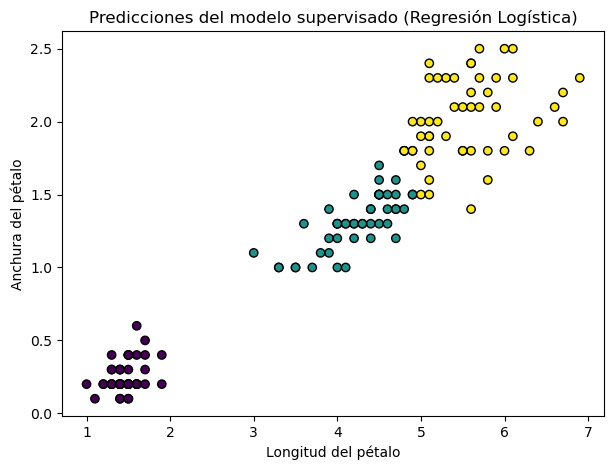

--- Evaluación del Modelo Supervisado ---
Accuracy: 0.9733

Matriz de Confusión:
[[50  0  0]
 [ 0 47  3]
 [ 0  1 49]]


In [27]:
# 4. Visualización de las predicciones
plt.figure(figsize=(7,5))
plt.scatter(X[:, 2], X[:, 3], c=y_pred_sup, cmap='viridis', edgecolors='k')
plt.xlabel("Longitud del pétalo")
plt.ylabel("Anchura del pétalo")
plt.title("Predicciones del modelo supervisado (Regresión Logística)")
plt.show()

# 5. Métricas para comparar con la realidad
print("--- Evaluación del Modelo Supervisado ---")
print(f"Accuracy: {accuracy_score(y, y_pred_sup):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y, y_pred_sup))

# 5. K-Means

Ahora aplicamos **K-Means** sobre el mismo conjunto de datos, pero sin utilizar las etiquetas reales.

Esto significa que el algoritmo:

- no sabe qué flor es setosa, versicolor o virginica;
- solo agrupa observaciones según su similitud.

Por tanto, los clusters obtenidos no tienen por qué coincidir exactamente con las clases reales.

In [28]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
clusters = kmeans.labels_


print("Primeros clusters asignados:", clusters[:20])
print("\nCentroides:")
print(kmeans.cluster_centers_)

Primeros clusters asignados: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Centroides:
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


In [31]:
# Pasamos los centroides de la escala normalizada a la escala real (cm)
# Esto es necesario porque el gráfico que haremos usa los datos originales X
centroides_reales = scaler.inverse_transform(kmeans.cluster_centers_)

print("Centroides convertidos a centímetros (listos para graficar):")
print(centroides_reales)


Centroides convertidos a centímetros (listos para graficar):
[[5.80188679 2.67358491 4.36981132 1.41320755]
 [5.006      3.428      1.462      0.246     ]
 [6.78085106 3.09574468 5.5106383  1.97234043]]


## 5.1 Visualización K - Means

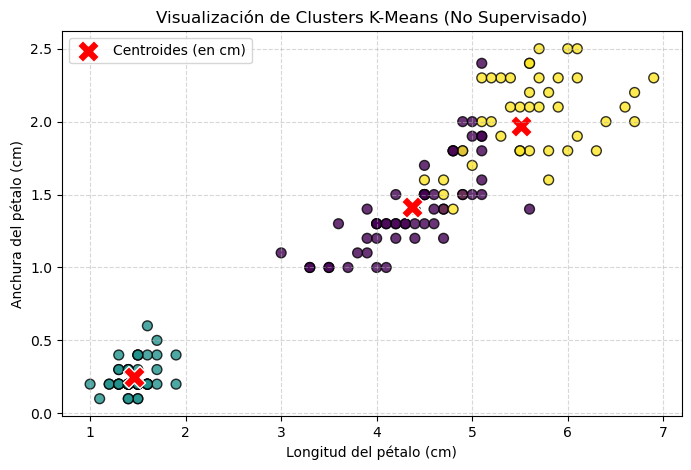

Coordenadas de los centroides en centímetros (Sepal L, Sepal W, Petal L, Petal W):
[[5.80188679 2.67358491 4.36981132 1.41320755]
 [5.006      3.428      1.462      0.246     ]
 [6.78085106 3.09574468 5.5106383  1.97234043]]


In [30]:

# tenemos que poder medir en cm. K-Means "ve" datos normalizados; sin emabrgo, estamos representando centímetros
# 1. Desnormalizar los centroides
# K-Means trabajó con X_scaled, así que sus centros están en esa escala.
# Los devolvemos a centímetros usando el scaler original.
centroides_cm = scaler.inverse_transform(kmeans.cluster_centers_)

# 2. Crear la gráfica
plt.figure(figsize=(8, 5))

# Graficamos los datos originales (X) que están en cm
# El color 'c' viene de los 'clusters' que asignó el modelo (0, 1 o 2)
plt.scatter(X[:, 2], X[:, 3], c=clusters, cmap='viridis', edgecolors='k', s=50, alpha=0.8)

# Graficamos los centroides ya convertidos a cm
# Usamos las columnas 2 y 3 que corresponden a los pétalos
plt.scatter(centroides_cm[:, 2], centroides_cm[:, 3], 
            marker='X', s=250, c='red', label='Centroides (en cm)', edgecolors='white')

plt.xlabel("Longitud del pétalo (cm)")
plt.ylabel("Anchura del pétalo (cm)")
plt.title("Visualización de Clusters K-Means (No Supervisado)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Mostrar los valores reales de los centros
print("Coordenadas de los centroides en centímetros (Sepal L, Sepal W, Petal L, Petal W):")
print(centroides_cm)

# 6. Comparación

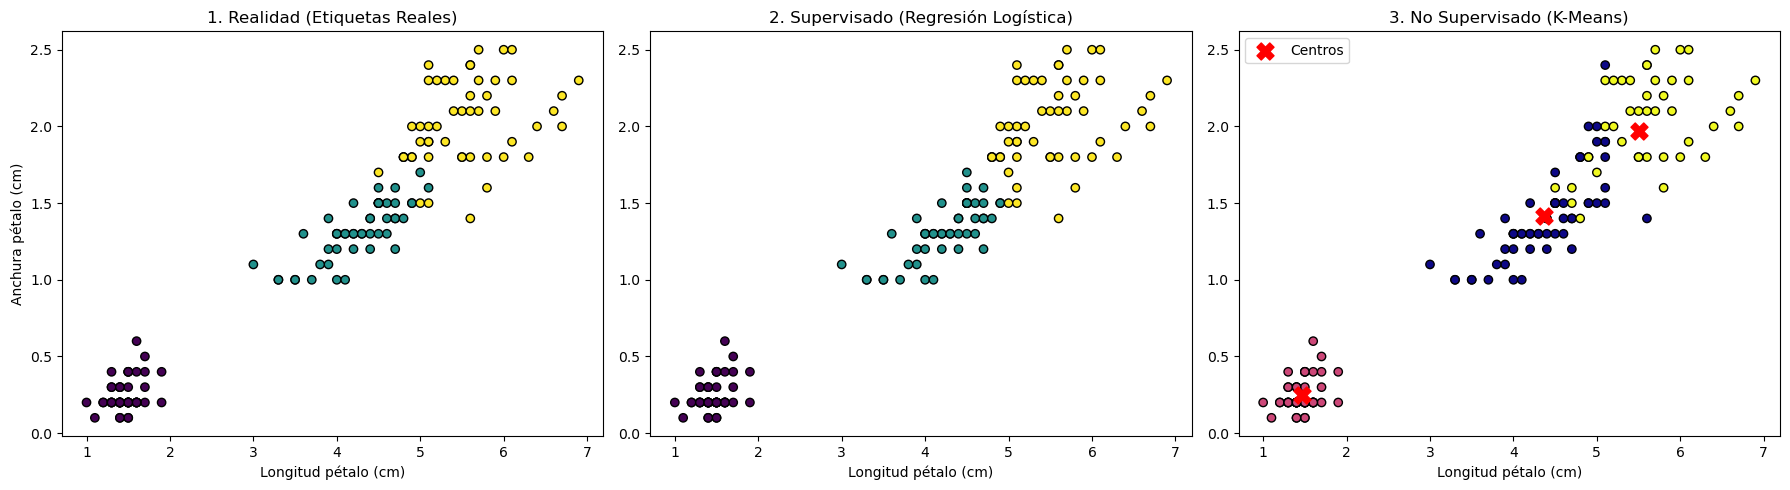

In [32]:
# gráficas que comparan todo lo visto hasta ahora
plt.figure(figsize=(18, 5))

# 1. LA REALIDAD (Etiquetas originales)
plt.subplot(1, 3, 1)
plt.scatter(X[:, 2], X[:, 3], c=y, cmap='viridis', edgecolors='k')
plt.title("1. Realidad (Etiquetas Reales)")
plt.xlabel("Longitud pétalo (cm)")
plt.ylabel("Anchura pétalo (cm)")

# 2. MODELO SUPERVISADO (Predicciones con etiquetas conocidas)
# Usamos y_pred_sup que calculaste con Regresión Logística
plt.subplot(1, 3, 2)
plt.scatter(X[:, 2], X[:, 3], c=y_pred_sup, cmap='viridis', edgecolors='k')
plt.title("2. Supervisado (Regresión Logística)")
plt.xlabel("Longitud pétalo (cm)")

# 3. MODELO NO SUPERVISADO (K-Means)
# Usamos 'clusters' y los centroides desnormalizados
plt.subplot(1, 3, 3)
plt.scatter(X[:, 2], X[:, 3], c=clusters, cmap='plasma', edgecolors='k')
plt.scatter(centroides_reales[:, 2], centroides_reales[:, 3], 
            marker='X', s=150, c='red', label='Centros')
plt.title("3. No Supervisado (K-Means)")
plt.xlabel("Longitud pétalo (cm)")
plt.legend()

plt.tight_layout()
plt.show()

# 7. Comparación entre clases reales y clusters

La siguiente tabla permite comparar:

- las clases reales del dataset Iris;
- los grupos generados por K-Means.

Importante:
los números de los clusters no representan directamente las especies.
Por ejemplo, el cluster 0 no tiene por qué corresponder a la clase 0.

Esta tabla sirve para ver qué especies quedan mejor agrupadas y cuáles se mezclan más.

In [ ]:
#pon el código aquí

# 8. Conclusiones

- El modelo supervisado aprende usando etiquetas reales.
- K-Means no utiliza etiquetas, solo busca agrupaciones por similitud.
- En el dataset Iris, la especie setosa suele quedar muy bien separada.
- Versicolor y virginica presentan más similitud y pueden mezclarse más.
- Un cluster no equivale necesariamente a una clase real.
- otras...

# 9. Cuestiones

1. ¿Por qué el modelo supervisado puede calcular su `accuracy`?
- Puede calcular el accuracy porque tiene acceso a las etiquetas reales.
2. ¿Por qué **K-Means** no puede compararse directamente con las clases reales usando solo los números de cluster?
- Porque K-Means la forma que tiene de trabajar son agrupaciones por distancia, K-Means no sabe de categorias biologicas en este caso del dataset de Iris.
3. ¿Qué especie parece separarse mejor en el dataset Iris?
- Parece que la que mejor se separa es la Iris Setosa, ya que es la que esta "apartada" de los otros dos grupos / clusters. Es la agrupación que tiene más distancia entre uno y otro.
4. ¿Qué diferencias observas entre clasificar y agrupar?
- Clasificar va por diferencias entre especies y agrupar lo relacionado mas a lo que hace K-Means, por ejemplo, trabajar con distancias.
5. ¿En qué casos reales tendría sentido usar un modelo supervisado y en cuáles **K-Means**?